# ADA 25: Exam (100 Points Total)

This exam consists of three main tasks, each with several questions. The tasks are independent of each other and can be solved in any order. 

**DO NOT WORRY IF YOU CAN NOT SOLVE ALL OF THESE TASKS!** The larger number of questions is intended to give you more opportunities to show what you have learned during the course :).

A shared "Google Doc" is available [here](https://docs.google.com/document/d/e/2PACX-1vQWG_J3UfU8WaVCly1HpPwCSf49sDHT6hjOQUSSFoJasENqUq_x2HHpqQoJ5m66gt2RmSJ0q9-ZJMQD/pub):
- Any announcements will be posted in this document
- Any questions emailed to <a href="ada-core-assistants-2025@groupes.epfl.ch">ada-core-assistants-2025@groupes.epfl.ch</a> will appear here

### Random Seed
**Important**: always use the `RANDOM_SEED = 4`, do **NOT** change this

In [131]:

import os
import random
import itertools
import numpy as np
import pandas as pd
import seaborn as sns
import networkx as nx
from scipy import stats
import matplotlib.pyplot as plt
from collections import defaultdict

from sklearn.decomposition import TruncatedSVD
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

RANDOM_SEED = 4

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

## Task 1 (40 Points): Good News Can't Wait?

For your first assignment you'll be exploring the conference acceptance process for a top-tier AI conference. Let's start with some background:

**The ICLR Review Process: A Brief Overview:**

The International Conference on Learning Representations (ICLR) is one of the most prestigious AI conferences. It employs a ``double-blind'' peer-review system, meaning the identities of both authors and reviewers are concealed throughout the process. The decision-making workflow generally follows these stages:

1. **Submission & Assignment**: Each paper is typically assigned 3 to 4 independent reviewers based on subject matter expertise, overseen by an Area Chair (AC).
2. **Initial Review Phase**: Reviewers submit independent scores and qualitative feedback.
3. **Discussion & Rebuttal**: Authors can respond to reviews, and reviewers may update their scores based on these discussions.
4. **Recommendation**: The AC synthesizes the reviews and the discussion to provide a Meta-Review and a final recommendation to the Program Chairs.
5. **Final Decision**: The Program Chairs make the ultimate acceptance decision. This is influenced not only by individual paper quality but also by the target acceptance rate for the conference and the total capacity of the venue.

In an effort to promote transparency, ICLR make both the reviews for the accepted **and** the rejected submissions available to the general public.

The ICLR review process is hosted by a website called "Openreview." 
Each paper submission gets its own webpage that shows the paper's title and abstract (short description of the paper) followed by the reviews.
Due to a "quirk" of Openreview, the webpage lists the reviews based on the date they were first posted (the most recent review is shown first). 
For the remainder of this task, we can thus assume the order is "randomly" assigned.
 
**The main focus of this task is to investigate if the order used to present the reviews matters for paper acceptance**

### 1.a: Causal Diagram (5 pts)
From the **AC's point of view**, please describe the causal DAG representing the acceptance recommendation using the following entities:
- paper
- reviews
- order
- AC recommendation

Describe the directed acyclic diagram (DAG) using equations of the form: A = f(B), C = g(E), etc.  
For each relation, provide a **short** justification.

Provide your solution in **markdown** (just simple text, no fancy plotting needed :))

/Discuss/:

**your answer**
reviews = f(paper)  Reviews are based on the paper

ac_recommendation = g(review,order)   after discussion the AC (Area Chair) decides if to send the recommendation above



### Data task 1 and 2

The data dictionary for task 1 and 2:
- `paper_id`: (str) unique paper ID
- `abstract`: (str) short description of the paper
- `track`: (str) the subject matter category the paper was submitted to
- `r1_score`: (float) the review score shown first
- `r2_score`: (float) the review score shown second
- `r3_score` (float) the review score shown third
- `r4_score`: Optional(float) IF four reviews, the review score shown fourth, ELSE None
- `num_reviews`: (int) the number of reviews the paper received
- `is_accepted`: (int) the final acceptance decision (0 is rejected, 1 is accepted)

In [132]:
# THIS IS THE DATA USED FOR TASK 1 and 2
import pandas as pd

df = pd.read_csv('data/task_1_2_data.csv')
df = df.astype({
    'paper_id': str,
    'abstract': str,
    'track': str,
    'is_accepted': int,
    'r1_score': float,
    'r2_score': float,
    'r3_score': float,
    'r4_score': float,
    'num_reviews': int
    })
df.head()

,paper_id,abstract,track,is_accepted,r1_score,r2_score,r3_score,r4_score,num_reviews
0,zz9jAssrwL,High-performance deep reinforcement learning f...,reinforcement learning,0,3.0,3.0,6.0,NaN,3
1,zyGrziIVdE,The ability to explore efficiently and effecti...,reinforcement learning,0,3.0,3.0,5.0,3.0,4
2,zxg6601zoc,Multimodal instruction tuning has proven to be...,"unsupervised, self-supervised, semi-supervised...",1,6.0,6.0,6.0,5.0,4
3,zxbQLztmwb,There is an open question of what types of num...,interpretability and explainable AI,0,3.0,5.0,6.0,5.0,4
4,zxO4WuVGns,Bayesian observer and actor models have provid...,applications to neuroscience & cognitive science,1,6.0,6.0,6.0,NaN,3


### 1.b Inspect the data (10 pts)
We'll start our investigation with some high-level data analysis:

1. (2 pts) Compute the overall acceptance rate of the conference and print it

In [133]:
acceptance_rate = df["is_accepted"].mean()
print("The acceptance rate is :", acceptance_rate)

The acceptance rate is : 0.3252350269356713


2. (2 pts) Compute the average score per paper into a new column `score_avg`

In [134]:
df["score_avg"] = (df["r1_score"].fillna(0)+ df["r2_score"].fillna(0)+ df["r3_score"].fillna(0)+ df["r4_score"].fillna(0)) / df["num_reviews"]
df.head()

,paper_id,abstract,track,is_accepted,r1_score,r2_score,r3_score,r4_score,num_reviews,score_avg
0,zz9jAssrwL,High-performance deep reinforcement learning f...,reinforcement learning,0,3.0,3.0,6.0,NaN,3,4.00
1,zyGrziIVdE,The ability to explore efficiently and effecti...,reinforcement learning,0,3.0,3.0,5.0,3.0,4,3.50
2,zxg6601zoc,Multimodal instruction tuning has proven to be...,"unsupervised, self-supervised, semi-supervised...",1,6.0,6.0,6.0,5.0,4,5.75
3,zxbQLztmwb,There is an open question of what types of num...,interpretability and explainable AI,0,3.0,5.0,6.0,5.0,4,4.75
4,zxO4WuVGns,Bayesian observer and actor models have provid...,applications to neuroscience & cognitive science,1,6.0,6.0,6.0,NaN,3,6.00


3. (2 pts) Plot a density histogram of these score averages using 20 bins.

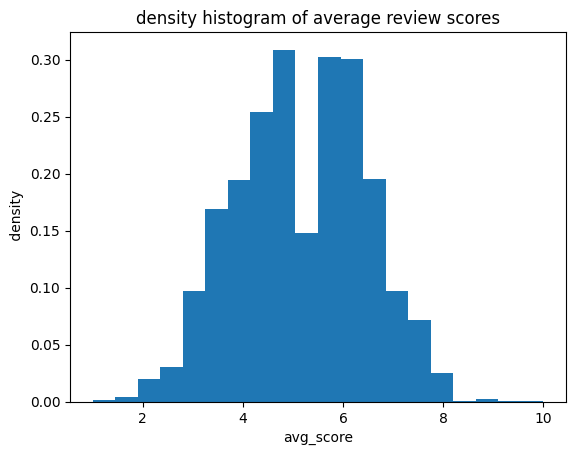

In [135]:
plt.hist(df["score_avg"],bins=20,density=True)
plt.xlabel("avg_score")
plt.ylabel(" density")
plt.title("density histogram of average review scores")
plt.show()

4. (2 pts) On a second plot, create a bar plot with `score_avg` bins on the x-axis (use bins with size 0.5) and the acceptance rate on the y-axis. Additionally, add a horizontal line with the overall acceptance rate. Make sure your plot has a clear legend and axes labels.

**Hint**: The "acceptance rate" is the mean of `is_accepted` for all papers in the applicable `score_avg` bin.

/var/folders/bh/2wy_2vwx61120cl4s5b0tlz80000gp/T/ipykernel_96442/1470337564.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("score_bins")["is_accepted"]


<class 'range'>


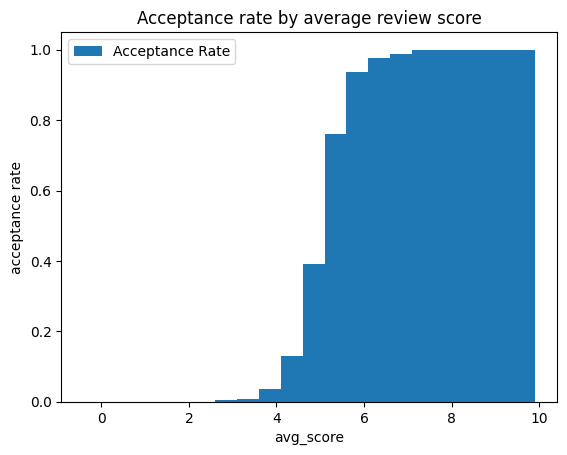

In [136]:
df_binned = df.copy()
df_binned["score_bins"] = pd.cut(df["score_avg"],bins=20)
df_for_plot = (
    df_binned
        .groupby("score_bins")["is_accepted"]
        .mean()
        .reset_index()
)


bin_range = [float(x/2) for x in range(0,20,1)]

print(range)
plt.bar(bin_range,df_for_plot["is_accepted"],label="Acceptance Rate")
plt.xlabel("avg_score")
plt.ylabel("acceptance rate")
plt.title("Acceptance rate by average review score")
plt.legend()
plt.show()

5. (2 pts) /Discuss/: Based on the two plots, provide score cutoffs for a "clear reject", "clear accept", and "borderline" region

**your answer**
0 <= Clear reject <=  4

4 < borderline < 7

7 <= clear accept <= 10



### 1.c. Factors of interest (15 pts)
We will start by first creating some features of interest to aid our analysis (1 to 3), which will then be used to fit a logistic regression (4), the results of which will be analyzed in (5).

1. (2 pts) Write a function that checks if the first score is the highest score and add this to the dataframe as new column `is_highest`.
    - Compute and print the average acceptance rate conditioned on the `is_highest` feature. That is: Compute and print the acceptance rate separately for papers where the first review score is the highest and for papers where it is not.
    - highest means: >=  **NOT**  >

In [137]:
df = df.fillna(0)

df["max"] = df[["r1_score","r2_score","r3_score","r4_score"]].max(axis=1)
df["is_highest"] = df["r1_score"] >= df["max"]
df.head()

,paper_id,abstract,track,is_accepted,r1_score,r2_score,r3_score,r4_score,num_reviews,score_avg,max,is_highest
0,zz9jAssrwL,High-performance deep reinforcement learning f...,reinforcement learning,0,3.0,3.0,6.0,0.0,3,4.00,6.0,False
1,zyGrziIVdE,The ability to explore efficiently and effecti...,reinforcement learning,0,3.0,3.0,5.0,3.0,4,3.50,5.0,False
2,zxg6601zoc,Multimodal instruction tuning has proven to be...,"unsupervised, self-supervised, semi-supervised...",1,6.0,6.0,6.0,5.0,4,5.75,6.0,True
3,zxbQLztmwb,There is an open question of what types of num...,interpretability and explainable AI,0,3.0,5.0,6.0,5.0,4,4.75,6.0,False
4,zxO4WuVGns,Bayesian observer and actor models have provid...,applications to neuroscience & cognitive science,1,6.0,6.0,6.0,0.0,3,6.00,6.0,True


2. ( 2pts) Write a function that computes the "consensus" of the reviewers measured by **standard deviation of the scores multiplied by -1** and adds this to the dataframe as new column `score_consensus`.
    - Compute and print the mean value of `score_consensus` across the dataset.

In [138]:

df["score_consensus"] = -1 * ((((df["r1_score"]-df["score_avg"])*(df["r1_score"]-df["score_avg"]) + (df["r2_score"]-df["score_avg"])*(df["r2_score"]-df["score_avg"]) + (df["r3_score"]-df["score_avg"])*(df["r3_score"]-df["score_avg"]) + (df["r4_score"]-df["score_avg"])*(df["r4_score"]-df["score_avg"]))/df["num_reviews"]).pow(1./2))

df.head()


,paper_id,abstract,track,is_accepted,r1_score,r2_score,r3_score,r4_score,num_reviews,score_avg,max,is_highest,score_consensus
0,zz9jAssrwL,High-performance deep reinforcement learning f...,reinforcement learning,0,3.0,3.0,6.0,0.0,3,4.00,6.0,False,-2.708013
1,zyGrziIVdE,The ability to explore efficiently and effecti...,reinforcement learning,0,3.0,3.0,5.0,3.0,4,3.50,5.0,False,-0.866025
2,zxg6601zoc,Multimodal instruction tuning has proven to be...,"unsupervised, self-supervised, semi-supervised...",1,6.0,6.0,6.0,5.0,4,5.75,6.0,True,-0.433013
3,zxbQLztmwb,There is an open question of what types of num...,interpretability and explainable AI,0,3.0,5.0,6.0,5.0,4,4.75,6.0,False,-1.089725
4,zxO4WuVGns,Bayesian observer and actor models have provid...,applications to neuroscience & cognitive science,1,6.0,6.0,6.0,0.0,3,6.00,6.0,True,-3.464102


3. (2 pts) Assume the borderline section starts at 4 and ends at 6.5 (both inclusive).
    - Add a `is_borderline` column and print the average acceptance rate for borderline papers.

In [139]:
df["is_borderline"] = df["score_avg"].apply(lambda x : 1 if (x <= 6.5 and x>=4) else 0)

print("acceptance for borderline papers: ", df.loc[df.is_borderline ==1]["is_accepted"].mean())

acceptance for borderline papers:  0.28659268146370726


4. (4 pts) Use the `logit` function from `statsmodels.formula.api` to perform a logistic regression on the subset of borderline papers (use the `is_borderline` column you added to filter these).
    - `is_accepted` is your target variable
    - `is_highest`, `score_consensus`, `num_reviews`, and `track` are your variables

In [140]:
from statsmodels.formula.api import logit

mod = logit(formula='is_accepted ~ C(is_highest) + score_consensus + num_reviews + C(track)', data=df)
res = mod.fit()
print(res.summary())

Optimization terminated successfully.
         Current function value: 0.620423
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:            is_accepted   No. Observations:                 9467
Model:                          Logit   Df Residuals:                     9443
Method:                           MLE   Df Model:                           23
Date:                Tue, 13 Jan 2026   Pseudo R-squ.:                 0.01638
Time:                        18:19:37   Log-Likelihood:                -5873.5
converged:                       True   LL-Null:                       -5971.3
Covariance Type:            nonrobust   LLR p-value:                 2.518e-29
                                                                                                         coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------

5. (5 pts) /Discuss/: Based on the results of (4), would you tentatively conclude the effect of review order on the final acceptance decision is significant at 95% CI? How do you interpret the `score_consensus` results?
    - First: compute the Odds Ratio (OR) for the `is_highest` variable, then interpret this value in plain english, e.g., "All things equal, the odds of a paper being accepted are [X] times higher if ..."
    - Second: what might be the relation between `is_highest` and `score_consensus`?


**Hint for 5**: 

_What happens to `is_highest` when there is perfect agreement among reviewers?_

In [141]:
value = 0.3534
x = np.exp(value)
print(x)

1.4239005897726504


All things equal, the odds of a paper being accepted are 1.4 times higher if ...

### 1.d Statistical Twins (10 pts)
To truly isolate the impact of the position of a review (the "champion" effect) from the quality of the paper, we use a matching strategy. By grouping papers into "Statistical Twins"—papers that received the exact same set of scores (e.g., three reviewers all gave a 5, 6, and 8)—we effectively hold paper quality constant. Within these identical sets, we can then ask: Does the specific behavior or timing of the 'highest' reviewer (the 8) change the outcome, even when the `signature` of the paper is identical? This approach mimics a controlled experiment, allowing us to see if the Area Chair is influenced by how a score sits within the distribution, rather than just the raw scores themselves.

1. (2 pts) Write a function that adds a review score `signature` column. That is: the set of scores a paper received.

**Hint**: Papers with (4, 5, 4) and (4, 4, 5) should get the same signature, while (5, 5, 4) should get a different one.

In [142]:
'''df["signature"] = int(df["r1_score"]).to_string() + int(df["r2_score"]).to_string() + int(df["r3_score"]).to_string()


def sign(str):
    nums = []
    for c in str:
        if c.isnumeric():
            nums.append(int(c))

    nums.sort()
    sign = str(nums[0]) + str(nums[1]) + str(nums[2])
    return sign

print(sign("0 3.0\n1 3.0\n2 6.0\n3"))

#df["signature"] = df["signature"].apply(lambda x: )
df.head()'''

'df["signature"] = int(df["r1_score"]).to_string() + int(df["r2_score"]).to_string() + int(df["r3_score"]).to_string()\n\n\ndef sign(str):\n    nums = []\n    for c in str:\n        if c.isnumeric():\n            nums.append(int(c))\n\n    nums.sort()\n    sign = str(nums[0]) + str(nums[1]) + str(nums[2])\n    return sign\n\nprint(sign("0 3.0\n1 3.0\n2 6.0\n3"))\n\n#df["signature"] = df["signature"].apply(lambda x: )\ndf.head()'

2. (2 pts) Filter out any non-borderline papers and any signatures that have fewer than 10 papers.

3. (4 pts) Perform an appropriate statistical test and report the p-value

4. (2 pts) /Discuss:/ What do you conclude at 95% CI?

**your answer**

## Task 2 (20 Points): You had me at Hello

While numerical scores and review order provide a structural view of the conference, the content of the research itself—expressed through the abstract contains the actual "signal" of innovation. In this section, we shift from review metadata to Natural Language Processing (NLP). Research papers often follow linguistic trends; certain methodologies (e.g., "diffusion models," "transformers") or buzzwords may be associated with higher acceptance rates in a given year.

### 2.a Buzzz words (10 pts)
1. (3 pts) Use `sklearn.feature_extraction.text.TfidfVectorizer` to transform the abstract column into a feature matrix $X$
    - Constraint 1: Remove English stop words to discard uninformative frequent terms.
    - Constraint 2: Use both unigrams (1-gram) and bigrams (2-gram) to capture phrases like "neural network".
    - Constraint 3: Limit max_features to 2,000 to avoid creating a matrix that is too sparse or high-dimensional.

In [143]:
vectorizer = TfidfVectorizer(
    max_features=2000,
    stop_words="english",
    ngram_range=(1,2)
)

X = vectorizer.fit_transform(df["abstract"])
X.shape

(9467, 2000)

2. (2 pts) Fit a Logistic Regression model (`sklearn.linear_model.LogisticRegression`) to predict is_accepted using the TF-IDF matrix.
    - Please use L1 (Lasso) regularization to penalize large weights, as text data often has more features than documents ($D > N$) which leads to overfitting. Use the following hyperparamers: `l1_ratio=0, C=1.0, solver='liblinear`.

In [144]:
from sklearn.linear_model import LogisticRegression

y = df["is_accepted"]


log_reg = LogisticRegression(l1_ratio=0,C=1.0,solver="liblinear")
log_reg.fit(X, y)



,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

3. (3 pts) Extract the model coefficients ($\beta$) and list the top 10 words (features) with the highest positive coefficients and the top 10 words with the lowest negative coefficients.

In [145]:

coefficients = log_reg.coef_[0]

# Highest positive weights → strongly predict success = 1
top_positive_indices = coefficients.argsort()[-10:][::-1]

# Most negative weights → strongly predict success = 0
top_negative_indices = coefficients.argsort()[:10]

# Map indices back to actual terms
vocabulary = vectorizer.get_feature_names_out()

top_positive_terms = [vocabulary[i] for i in top_positive_indices]
top_negative_terms = [vocabulary[i] for i in top_negative_indices]

print(f"Top 10 terms: {top_positive_terms}")
print(f"Bot 10 terms: {top_negative_terms}")

Top 10 terms: ['github', 'github com', 'https github', 'com', 'https', 'available https', 'github io', 'io', 'project', 'code available']
Bot 10 terms: ['anonymous', 'https anonymous', 'anonymous 4open', '4open', '4open science', 'domain', 'textit', 'science', 'paper', 'addressing']


Once a paper is accepted, authors are asked to provide a _camera-ready_ version. This means authors can update their paper, which can also change the abstract.

4. (2 pts) /Discuss/: Carefully examine the top words for the rejected and accepted papers:
    - If your goal was to help an author predict if their paper would be accepted based only on the abstract, why is this current model "useless"?


**Hint, 4**:

_Use your knowledge of the double-blind review policy (where the identity of the authors and reviewers should remain anonymous)_

**your answer**:
The abstract explains the general approach, goals, methods used to solve or investigate some theory or problem. Our top terms suggest that authors which have open sourced their code, have a website or have available content are more likely to succeed. And this is not usually written in the abstract.

### 2.b Topics Matter? (10 pts)
Individual keywords are often noisy and can be influenced by formatting or procedural artifacts. To capture the underlying research themes of the ICLR corpus, we must shift our analysis from vocabulary to latent concepts.

1. (3 pts) Use ``TruncatedSVD`` from ``sklearn.decomposition`` (Latent Semantic Analysis) to factorize your TF-IDF matrix into 50 latent components, ensuring you set random_state=RANDOM_SEED.
    - Identify the Theme: Extract and print the top 10 words associated with the second component (index 1).
    - **Mathematical Context**: _This process approximates the decomposition $T \approx USV^T$. By analyzing the components, we are examining the "Topic Space" where words that frequently co-occur are grouped into singular axes of variance._

In [146]:
from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(n_components=50,random_state=RANDOM_SEED)
svd.fit(X,y)

coefficients = svd.components_[1]

# Highest positive weights → strongly predict success = 1
top_positive_indices = coefficients.argsort()[-10:][::-1]

# Map indices back to actual terms
vocabulary = vectorizer.get_feature_names_out()

top_positive_terms = [vocabulary[i] for i in top_positive_indices]

print(f"Top 10 terms: {top_positive_terms}")



Top 10 terms: ['llms', 'reasoning', 'language', 'llm', 'language models', 'large language', 'models', 'models llms', 'human', 'large']


2. (3 pts) Create a new column in your dataframe called `topic_1_strength` using the values from this second component. Generate a scatter plot with a linear regression trend line to visualize the relationship between a paper's alignment with this topic and its `score_avg`.

3. (4 pts) Calculate the Pearson correlation coefficient ($r$) and its associated p-value.
    - /Discuss/: Based on your p-value, is the relationship between this topic and review scores statistically significant at the $\alpha = 0.05$ level?
    - /Discuss/: Examine the magnitude of the correlation coefficient. In the context of a competitive peer-review process, how much of the variance in scores is actually explained by a paper’s alignment with this dominant topic? Contrast the statistical significance with the practical meaningfulness of this effect.

In [147]:
# Coding part

**Discussion answers**:

## Task 3 (40 Points): Minds of a Matter Publish Together

In the final stage of our analysis, we move beyond the text of the paper and the mechanics of the review process to examine the social topology of the ICLR community. Science is rarely a solitary endeavor; it is conducted within a network of collaborators, laboratories, and institutions.

In this section, you will treat the conference as a Co-authorship Network. By representing authors as nodes and their collaborations as edges, you will investigate whether the "connectedness" of an author—their position within the global research web—relates to the likelihood of their work being accepted. Is acceptance purely a meritocracy of ideas, or do structural advantages within the social graph play a role in the "minds of a matter" publishing together?

### Data task 3

The data dictionary for task 3:
- `paper_id`: (str) unique paper ID
- `authorids`: (list[str]) the unique IDs of authors listed on a paper
- `is_accepted`: (int) the final acceptance decision (0 is rejected, 1 is accepted)

In [148]:
import pandas as pd

df_papers = pd.read_csv('data/task_3_data.csv')
df_papers['authorids'] = df_papers['authorids'].apply(eval)
df_papers.head()

,paper_id,authorids,is_accepted
0,zzk231Ms1Ih,"[~Arun_Rajkumar4, ~Vishnu_Veerathu1, cs20d400@...",1
1,zz9hXVhf40,"[~Cong_Lu1, ~Philip_Ball1, ~Jack_Parker-Holder...",1
2,zyrhwrd9EYs,"[~Jeroen_Berrevoets1, ~Fergus_Imrie1, ~Trent_K...",0
3,zxEfpcmTDnF,"[~Samir_Alain_Sadok1, ~Simon_Leglaive1, lauren...",0
4,zuqcmNVK4c2,"[~Navid_Kardan1, ~Mubarak_Shah3, ~Mitch_Hill1]",1


### 3.a: Preparing the data (8pts)
1. (2 pts) /Discuss/: We have removed all papers that had more than 13 authors (<1% of the papers). Why might we do this?

**your answer**
Papers with more than 13 authors are problematic, since its hard to weight how much an author is part of the research (they could have been mentionned for little contribution) And this would make our network have more edges, but which are not very informative.

2. (2 pts) /Discuss/: We also want to exclude all authors that have fewer than 3 paper from this analysis. Why?


**your answer**
Authors with less than 3 papers aren't generally accpeted by the scientific community and might have little chances to be part of a collaboration, this would again add more noise to our network (many of them could create separate components)

3. (2 pts) Use `df_papers` to create an undirected graph where authors are nodes and edges indicate collaboration on a paper.

**important**: Only include authors that have at least 3 papers. This means that you should **not** add edges between authors *with* at least 3 papers and authors *without* at least papers.

In [149]:
df_papers.head()

,paper_id,authorids,is_accepted
0,zzk231Ms1Ih,"[~Arun_Rajkumar4, ~Vishnu_Veerathu1, cs20d400@...",1
1,zz9hXVhf40,"[~Cong_Lu1, ~Philip_Ball1, ~Jack_Parker-Holder...",1
2,zyrhwrd9EYs,"[~Jeroen_Berrevoets1, ~Fergus_Imrie1, ~Trent_K...",0
3,zxEfpcmTDnF,"[~Samir_Alain_Sadok1, ~Simon_Leglaive1, lauren...",0
4,zuqcmNVK4c2,"[~Navid_Kardan1, ~Mubarak_Shah3, ~Mitch_Hill1]",1


In [150]:
from itertools import chain

unique_authors = set()

for authors in df_papers["authorids"]:
    unique_authors.update(authors)



zeros = [0 for x in range(len(unique_authors))]

counter = dict(zip(list(unique_authors),zeros))


for authors in df_papers["authorids"]:
    for author in authors:
        counter[author]+=1



4. (2 pts) Print the total number of nodes and edges

In [151]:
print("nodes", len(unique_authors))

nodes 60654


### 3.b: Network Feature Engineering (12 pts)
To understand what drives success, we must move beyond simple counts (like number of papers) and quantify an author's structural position. Are they a "hub" connected to many? Are they "influential" by connecting to other key players? Or are they stuck in a tight "clique"? We will create features to measure these distinct properties.

#### 3.b.1: Network Metrics (6 pts)
1. (2 pts) Plot the degree distribution using a log plot.
    - /Discuss/: Does this network follow a power-law distribution?


2. (2 pts) Use the network graph you created to compute the following network metrics for each author: degree, pagerank, cluster coefficient

3. (2 pts) Create a dataframe called `df_features_network` that has the columns: "author_id", "degree", "pagerank", "cluster_coeff" and print the first five rows

#### 3.b.2: Paper Metrics (6 pts)

Use the `df_papers` dataframe as provided at the beginning of Task 3 to create a new dataframe called `df_features_author` that contains the following collumns:
1. `author_id`
2. `number_of_papers`, the number of papers the author wrote
3. `average_num_collaborators`, the average number of collaborators (other authors) per paper
4. `acceptance_rate`, the average acceptance probabilty of `is_accepted` across papers

Please print the first 5 rows.

In [152]:
papers = df_papers["paper_id"].unique()
print(len(papers))

df_papers_copy = df_papers.copy().set_index("paper_id")

df_papers_copy.head()

paper_to_author = dict(zip(papers,df_papers_copy["authorids"]))
print(paper_to_author.keys())

27186
dict_keys(['zzk231Ms1Ih', 'zz9hXVhf40', 'zyrhwrd9EYs', 'zxEfpcmTDnF', 'zuqcmNVK4c2', 'zuDmDfeoB_1', 'zrdUVVAvcP2', 'zrW-LVXj2k1', 'zq1iJkNk3uN', 'ziRLU3Y2PN_', 'zhynF6JnC4q', 'zfmB5vgfaCt', 'zf_Ll3HZWgy', 'zeGpMIt6Pfq', 'zbZL1s-pBF', 'zaALYtvbRlH', 'zXne1klXIQ', 'zXM0b4hi5_B', 'zU2v47WF0Ku', 'zRb7IWkTZAU', 'zRJu6mU2BaE', 'zPLQSnfd14w', 'zNR43c03lRy', 'zNHzqZ9wrRB', 'zLb9oSWy933', 'zKbMQ2NY1y', 'zIUyj55nXR', 'zHZ1mvMUMW8', 'zFyCvjXof60', 'zFlFjoyOW-z', 'zBhwgP7kt4', 'zBOI9LFpESK', 'zAyZFRptzvh', 'z8xVlqWwRrK', 'z8j0bPU4DIw', 'z7DAilcTx7', 'z3Tf4kdOE5D', 'z2zmSDKONK', 'z2B0JJeNdvT', 'z1-I6rOKv1S', 'z-5BjnU3-OQ', 'yztpblfGkZ-', 'yzDTTtlIlMr', 'yuv0mwPOlz3', 'yrD7B9N_54F', 'yql6px0bcT', 'youe3QQepVB', 'yjxVspo7gXt', 'yjsA8Uin-Y', 'yjMQuLLcGWK', 'yhjfOvBvvmz', 'yhCp5RcZD7', 'ygGMP1zkiD1', 'yfe1VMYAXa4', 'yeP_zx9vqNm', 'ydopy-e6Dg', 'ybsh6zEzIKA', 'y_tIL5vki1l', 'y_op4lLLaWL', 'yXBb-0cPSKO', 'yV4_fWe4nM', 'ySQH0oDyp7', 'yRYtnKAZqxU', 'yOBqNg-CqB0', 'yK_jcv_aLX', 'yKIAXjkJc2F', 'yCS5dck

In [153]:

df_features_author = pd.DataFrame()
df_features_author["author_id"] = list(unique_authors)


df_features_author["number_of_papers"] = df_features_author["author_id"].apply(lambda x: counter[x])
df_features_author.head()


,author_id,number_of_papers
0,~Tianqi_Chen1,2
1,~Saverio_Salzo1,1
2,~Xingrui_Gu1,1
3,~Jun_Wang1,4
4,~Yuki_Ishihara1,1


### 3.c Analysis (10 pts)
The average acceptance rate for top conferences often lies around 33%. We could therefore classify "successful authors" as those with an acceptance rate of >40%.
1. (2 pts) First merge `df_features_network` and `df_features_author` using an `inner` merge operation to create `df_features` 

In [154]:
 # df_features = pd.merge(df_features_author,df_features_network,how="inner", on="authord_id")

 # No dataframe feautre_network so I commented this part


2. (2 pts) Add a new column to your dataframe for successful authors called `is_successful` using the rule `acceptance_rate` > 0.4

3. (3 pts) Compute the correlations of the features with respect to the `is_successful` column. Additionally, perform a groupby on `is_successful` with respect to the features printing the mean and standard errors.

4. (3 pts) /Discuss/:  Observe the correlations for `degree` and `cluster_coeff`. Using the "structural holes" theory, how could one interpret these results?

**your answer**

### 3.d Prediction (10 pts)
We have seen some interesting correlations in the previous question. Let's see if we can use this to "predict" if a paper will be accepted!
1. (2 pts) Create three new column in the df_papers dataframe: `avg_degree, avg_pagerank, avg_cluster_coeff`. Populate these by calculating the "mean" of the respective metrics for all **active authors** on that paper (these should be the ones in the `df_features` dataframe!).

2. (1 pts) Define `X` as the features data using the three new features and `y` as the `is_accepted` column

3. (1 pts) Split the data into 80% training and 20% testing sets using `random_state=RANDOM_SEED`

4. (1 pts) Train a `LogisticRegression` classifier on the training set

5. (1 pts) Predict the `y` for the test set.

6. (2 pts) Print the accuracy score and print the `Coefficients` of the model to identify which network feature is the strongest predictor of acceptance.

7. (2 pts) /Discuss/: Given that the average baseline acceptance rate is ~33%, do the network features provide a meaningful signal for predicting paper acceptance?

**your answer**